Now we implement the Principal component analysis from the cleaned data that we prepared in the previous notebook

In [2]:
#These are all the required libraries for the PCA.

import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import norm


In [6]:
#df=pd.read_csv('../data/processed/cleaned_yield_changes.csv')
df=pd.read_csv('../data/processed/annual_rolling_changes.csv')
df.head()

,Date,6M_1Y_Change,1Y_1Y_Change,2Y_1Y_Change,3Y_1Y_Change,5Y_1Y_Change,7Y_1Y_Change,10Y_1Y_Change
0,1990-01-02,-1.16,-1.07,-0.79,-0.60,-0.28,-0.08,0.03
1,1990-01-03,-1.23,-1.13,-0.86,-0.69,-0.36,-0.18,-0.06
2,1990-01-04,-1.08,-0.99,-0.75,-0.56,-0.26,-0.08,0.04
3,1990-01-05,-1.01,-0.95,-0.70,-0.51,-0.17,0.01,0.14
4,1990-01-08,-1.14,-1.06,-0.75,-0.56,-0.18,0.01,0.14


In [7]:
#We will have to drop the date column as it is not a numerical value and will not be used in the PCA. We will also have to standardize the data before applying PCA.

x=df.drop(columns=['Date'])

scaler=StandardScaler()

x_c= scaler.fit_transform(x)


#We are following mathematical notation where x is the yield changes data, x_c is the standardized yield changes data.

#Standardization is as follows

#standardized value = (actual value - column mean) / column standard deviation

#We standardised the tenors to prevent high-volatility maturities from dominating the PCA.

In [8]:
#Now we run PCA on the standardized data.

pca=PCA()
pca_results=pca.fit_transform(x_c)

pca_results2=pd.DataFrame(pca_results,
                          columns=[f'PC{i+1}' for i in range(pca_results.shape[1])])
print(pca_results.shape)
pca_results2.head()

(8255, 7)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,-0.840361,-0.875550,0.078011,-0.005136,0.018573,-0.021051,-0.003670
1,-1.025283,-0.819966,0.065289,0.000421,0.010316,-0.012096,-0.013454
2,-0.764283,-0.826774,0.084851,0.001867,0.007623,-0.016386,0.003518
3,-0.599635,-0.895971,0.120903,-0.007833,-0.000561,-0.021612,-0.005631
4,-0.694162,-0.981375,0.104818,-0.009608,0.003619,-0.022807,-0.019303


In [9]:
# Now we see some key stats

explained_variance = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained Variance": pca.explained_variance_ratio_,
    "Cumulative Variance": pca.explained_variance_ratio_.cumsum()
})

print(explained_variance)

#PCA Components/eigenvectors
loadings_df = pd.DataFrame(
    pca.components_,
    columns=x.columns,
    index=[f'PC{i+1}' for i in range(pca.components_.shape[0])]
)

loadings_df

    PC  Explained Variance  Cumulative Variance
0  PC1            0.904688             0.904688
1  PC2            0.085787             0.990475
2  PC3            0.008144             0.998619
3  PC4            0.000905             0.999524
4  PC5            0.000225             0.999749
5  PC6            0.000166             0.999915
6  PC7            0.000085             1.000000


,6M_1Y_Change,1Y_1Y_Change,2Y_1Y_Change,3Y_1Y_Change,5Y_1Y_Change,7Y_1Y_Change,10Y_1Y_Change
PC1,0.357271,0.375400,0.390788,0.394232,0.388826,0.376994,0.360538
PC2,0.540667,0.418889,0.194189,0.025479,-0.251176,-0.402845,-0.518150
PC3,0.512601,0.123378,-0.397140,-0.512280,-0.224881,0.101116,0.490990
PC4,-0.385443,0.326106,0.359522,0.010218,-0.408122,-0.420764,0.521653
PC5,-0.119015,0.082853,0.265127,-0.115899,-0.595506,0.701500,-0.220262
PC6,-0.392038,0.721503,-0.283902,-0.301689,0.320756,0.117217,-0.193644
PC7,-0.029186,0.186032,-0.609677,0.690614,-0.333283,0.049820,0.048235


So 3 PC's explain 99.8619% of the variance. Taking 3 PC's is a standard procedure. They denote level, slope and curvature movement respectively

In [10]:
#Now since we only need the first 3 pc's we re run the code setting the number of components to 3

pca=PCA(n_components=3)
pca_results=pca.fit_transform(x_c)

#just to ensure that we get the same explained variance as before we print the explained variance again.

explained_variance = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained Variance": pca.explained_variance_ratio_,
    "Cumulative Variance": pca.explained_variance_ratio_.cumsum()
})

print(explained_variance)

    PC  Explained Variance  Cumulative Variance
0  PC1            0.904688             0.904688
1  PC2            0.085787             0.990475
2  PC3            0.008144             0.998619


In [11]:
#Our analysis holds true even with 3 PC's. We shouldn't expect anything different. This is a deterministic process. The PCA is a linear transformation and the first 3 PC's will always explain the same amount of variance regardless of how many PC's we choose to keep unless we change the data itself.

#Usually from what I have observed, the researchers ususally take up 2,3 and 4 PC's to compare the results. We will not do that. This whole project is to make sure conceptually we understand how the PCA works and how we implement the vasicek model to simulate the yield curve.

loadings=pd.DataFrame(pca.components_.T, columns=[f"PC{i+1}" for i in range(pca.n_components_)], index=x.columns)

print(loadings)

#The loadings are the weights of each feature in the principal components. They tell us how much each feature contributes to each principal component. The higher the absolute value of the loading, the more important that feature is in that principal component.



                    PC1       PC2       PC3
6M_1Y_Change   0.357271  0.540667  0.512601
1Y_1Y_Change   0.375400  0.418889  0.123378
2Y_1Y_Change   0.390788  0.194189 -0.397140
3Y_1Y_Change   0.394232  0.025479 -0.512280
5Y_1Y_Change   0.388826 -0.251176 -0.224881
7Y_1Y_Change   0.376994 -0.402845  0.101116
10Y_1Y_Change  0.360538 -0.518150  0.490990


Its a good idea to understand what the PC'S tell us. Here is my interpretation of it. We know that PC1, 2 3 give us level, slope and curvature. Here is what their values tell us

PC	Interpretation	Why
PC1	Level factor	All maturities are positive and fairly similar
PC2	Slope factor	Short maturities are positive, long maturities are negative
PC3	Curvature factor	Short and long ends are positive, middle maturities are negative

A broad strokes, high level interpretation is

On most days the maturities move together. They rise and fall together. This explains the bulk of the movement (PC1)

Sometimes the short rates and long rates move in opposite direction (PC2)

middle maturities behave differently in comparison to short and long maturities (PC3)

In [12]:
loadings.info()

<class 'pandas.DataFrame'>
Index: 7 entries, 6M_1Y_Change to 10Y_1Y_Change
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PC1     7 non-null      float64
 1   PC2     7 non-null      float64
 2   PC3     7 non-null      float64
dtypes: float64(3)
memory usage: 610.0 bytes


In [13]:
#Now we need PC scores which are the projections of the original data onto the principal components.

pc_scores=pd.DataFrame(pca_results, columns=[f"PC{i+1}" for i in range(pca.n_components_)], index=df.index)


#PC scores tell you the amount of movement on each date.


#We need to attach a date column to the pc_scores dataframe so that we can plot the pc scores over time.

pc_scores=pd.concat([df['Date'], pc_scores], axis=1)

pc_scores["Date"] = pd.to_datetime(pc_scores["Date"])

pc_scores.info()



<class 'pandas.DataFrame'>
RangeIndex: 8255 entries, 0 to 8254
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    8255 non-null   datetime64[us]
 1   PC1     8255 non-null   float64       
 2   PC2     8255 non-null   float64       
 3   PC3     8255 non-null   float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 258.1 KB


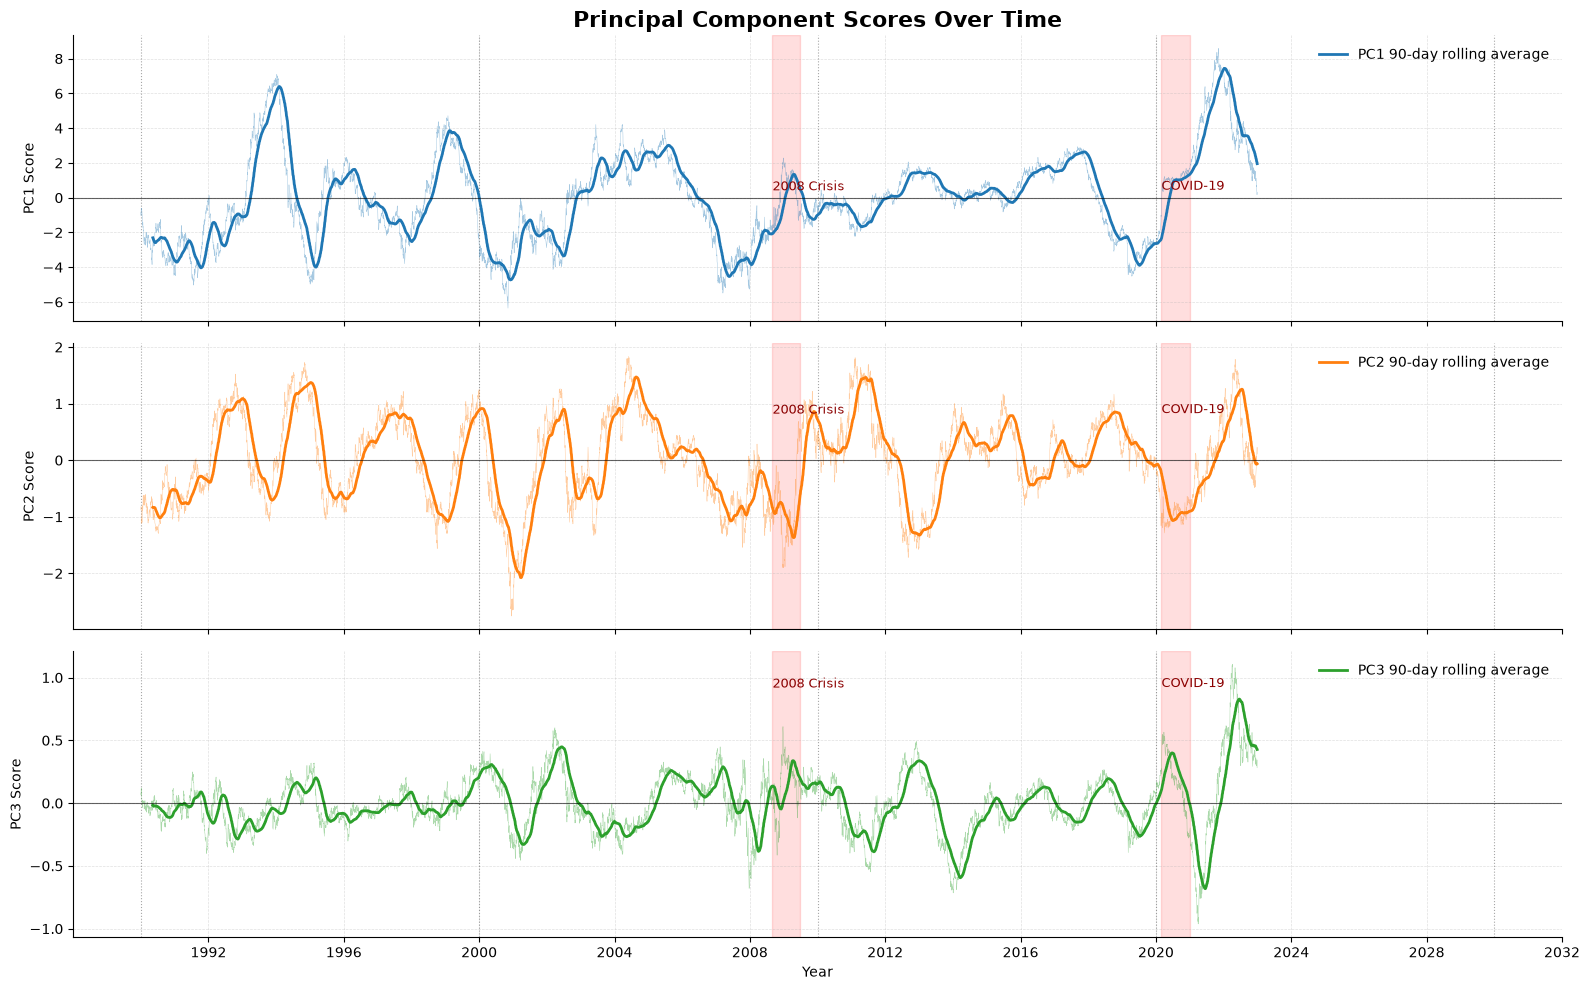

In [14]:
#We should plot the pc scores over time to see how they change over time. We will also add some shading to indicate stress periods in the market.
import matplotlib.dates as mdates

pc_scores["Date"] = pd.to_datetime(pc_scores["Date"])
pc_scores = pc_scores.sort_values("Date")

stress_periods = {
    "2008 Crisis": ("2008-09-01", "2009-06-30"),
    "COVID-19": ("2020-03-01", "2020-12-31")
}

pcs = ["PC1", "PC2", "PC3"]

colors = {
    "PC1": "#1f77b4",
    "PC2": "#ff7f0e",
    "PC3": "#2ca02c"
}

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

for ax, pc in zip(axes, pcs):

    # Decade separators
    for year in range(1990, 2031, 10):
        ax.axvline(
            pd.to_datetime(f"{year}-01-01"),
            color="black",
            linestyle=":",
            linewidth=0.8,
            alpha=0.35
        )

    # Stress period shading
    for label, (start, end) in stress_periods.items():
        start = pd.to_datetime(start)
        end = pd.to_datetime(end)

        ax.axvspan(
            start,
            end,
            color="red",
            alpha=0.13
        )

        ax.text(
            start,
            ax.get_ylim()[1],
            label,
            fontsize=9,
            color="darkred",
            verticalalignment="top"
        )

    # Raw daily PC scores - very faint
    ax.plot(
        pc_scores["Date"],
        pc_scores[pc],
        color=colors[pc],
        linewidth=0.35,
        alpha=0.4
    )

    # 90-day rolling average - main story line
    ax.plot(
        pc_scores["Date"],
        pc_scores[pc].rolling(90).mean(),
        color=colors[pc],
        linewidth=2.0,
        label=f"{pc} 90-day rolling average"
    )

    # Zero line
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)

    ax.set_ylabel(f"{pc} Score")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
    ax.legend(loc="upper right", frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_title(
    "Principal Component Scores Over Time",
    fontsize=16,
    weight="bold"
)

axes[-1].set_xlabel("Year")

axes[-1].xaxis.set_major_locator(mdates.YearLocator(4))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

In [15]:
tenors=x.columns.tolist()

#Independent variables ie pc scores

X_reg=pca_results

Y_reg=pd.DataFrame(
    x_c,
    columns=tenors,
    index=df.index
)

#We will have no intercepts/ negligeble intercepts since the standardized pc and scores are centered

model=LinearRegression(fit_intercept=False)

#Now we fit simultaneosly

model.fit(X_reg,Y_reg)

#use sklearn to get shape

regression_betas=pd.DataFrame(
    model.coef_,
    index=tenors,
    columns=["PC1_Beta","PC2_Beta","PC3_Beta"]
)

print(regression_betas)

loadings

               PC1_Beta  PC2_Beta  PC3_Beta
6M_1Y_Change   0.357271  0.540667  0.512601
1Y_1Y_Change   0.375400  0.418889  0.123378
2Y_1Y_Change   0.390788  0.194189 -0.397140
3Y_1Y_Change   0.394232  0.025479 -0.512280
5Y_1Y_Change   0.388826 -0.251176 -0.224881
7Y_1Y_Change   0.376994 -0.402845  0.101116
10Y_1Y_Change  0.360538 -0.518150  0.490990


,PC1,PC2,PC3
6M_1Y_Change,0.357271,0.540667,0.512601
1Y_1Y_Change,0.375400,0.418889,0.123378
2Y_1Y_Change,0.390788,0.194189,-0.397140
3Y_1Y_Change,0.394232,0.025479,-0.512280
5Y_1Y_Change,0.388826,-0.251176,-0.224881
7Y_1Y_Change,0.376994,-0.402845,0.101116
10Y_1Y_Change,0.360538,-0.518150,0.490990


In [16]:
#std deviation of the PC'scaler

print(np.sqrt(pca.explained_variance_[:3]))

[2.51666096 0.77497307 0.23877069]


In [17]:
# Variances of PC1, PC2, PC3
pc_variances = pca.explained_variance_[:3]

# Z-values
z_up = norm.ppf(0.995)
z_down = norm.ppf(0.005)

# Variance of each standardized tenor explained by the first 3 PCs
tenor_variance = (
    regression_betas["PC1_Beta"]**2 * pc_variances[0]
    + regression_betas["PC2_Beta"]**2 * pc_variances[1]
    + regression_betas["PC3_Beta"]**2 * pc_variances[2]
)

# Standard deviation for each tenor
tenor_std = np.sqrt(tenor_variance)

# Standardized stresses
stress_standardized = pd.DataFrame({
    "Downstress": z_down * tenor_std,
    "Upstress": z_up * tenor_std
})

stress_standardized

#Output is symettric due to N(0,1)

,Downstress,Upstress
6M_1Y_Change,-2.574513,2.574513
1Y_1Y_Change,-2.574299,2.574299
2Y_1Y_Change,-2.574381,2.574381
3Y_1Y_Change,-2.575454,2.575454
5Y_1Y_Change,-2.573666,2.573666
7Y_1Y_Change,-2.573518,2.573518
10Y_1Y_Change,-2.573607,2.573607


In [18]:
stress_original = pd.DataFrame(index=x.columns)

stress_original["Downstress"] = (
    scaler.mean_
    + scaler.scale_ * stress_standardized["Downstress"]
)

stress_original["Upstress"] = (
    scaler.mean_
    + scaler.scale_ * stress_standardized["Upstress"]
)

stress_percent=stress_original*100

stress_percent.columns=[
    "Downstress_Percent",
    "Upstress_Percent"
]

stress_percent.style.format("{:.2f}%")

,Downstress_Percent,Upstress_Percent
6M_1Y_Change,-391.85%,376.32%
1Y_1Y_Change,-376.79%,359.84%
2Y_1Y_Change,-349.62%,328.00%
3Y_1Y_Change,-327.68%,303.78%
5Y_1Y_Change,-290.44%,264.38%
7Y_1Y_Change,-268.48%,241.32%
10Y_1Y_Change,-247.36%,219.59%
